©2026. For information, contact Deloitte Tohmatsu Group.

# 📝 演習概要

この演習では、GRU（Gated Recurrent Unit）をNumPy/CuPyでスクラッチ実装します。リセットゲート・更新ゲートの動作をコードで再現し、RNNのベースモデルとGRUモデルの学習結果を比較することで、ゲート機構による勾配消失問題の改善効果を確認します。

# 事前準備

[JDLAが策定しているバージョン](https://www.jdla.org/certificate/engineer/)に合わせるために、以下のセルの実行をお願いします．

（#コメントアウト されているものは必要ありません）

また実行完了後に「ランタイムの再起動」をして下さい．

（以下のセルの実行は、最初にしていただければ、以降必要ありません．）

In [ ]:
# %%capture
# !pip uninstall matplotlib -y
# !pip install matplotlib==3.9.4

# !pip uninstall opencv-python -y
# !pip install opencv-python==4.11.0.86

# !pip uninstall torch -y
# !pip install torch==2.7.0

# !pip uninstall torchvision -y
# !pip install torchvision==0.22.0

In [ ]:
# ライブラリのインポート
import matplotlib.pyplot as plt

# GRU

GRUの説明をしていますが、学習を高速化するため実際にはTimeGRUを使用しています

### GPUの設定

In [ ]:
# GPUの設定
# True: GPU使用（cupy）, False: CPU使用（numpy）
GPU = True
#GPU = False

if GPU:
    # GPU使用時の設定
    import cupy as np
    import cupyx
    np.cuda.set_allocator(np.cuda.MemoryPool().malloc)

    # GPU使用モードの表示（緑色のテキストで視覚的に分かりやすく）
    print('\033[92m' + '-' * 60 + '\033[0m')               # 緑色の区切り線
    print(' ' * 23 + '\033[92mGPU Mode (cupy)\033[0m')     # 緑色でGPUモード表示
    print('\033[92m' + '-' * 60 + '\033[0m\n')             # 緑色の区切り線 + 改行
else:
    # CPU使用時の設定
    import numpy as np            # 標準のnumpyをインポート

------------------------------------------------------------
                       GPU Mode (cupy)
------------------------------------------------------------



In [ ]:
def to_cpu(x):
    import numpy
    if type(x) == numpy.ndarray:
        return x
    return np.asnumpy(x)


def to_gpu(x):
    import cupy
    import cupyx
    if type(x) == cupy.ndarray:
        return x
    return cupy.asarray(x)

### 利用する基本的な層クラスの設定

In [ ]:
# TImeRNN層の設定
# T個(Tは任意の数)のRNNレイヤから構成される層
class TimeRNN:
    def __init__(self, Wx, Wh, b, stateful=False):  # statefulはTimeRNN層の隠れ状態を維持するかしないかを意味する。長い時系列データを維持するときはTrueにする必要がある。
        # パラメータWx:(D,H), Wh:(H,H), b:(H,) を1レイヤ分として保持
        self.params = [Wx, Wh, b]
        # 各パラメータと同形状の勾配バッファを確保
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        # 各時刻のRNNレイヤ（展開されたセル）を保持するリスト
        self.layers = None

        # 現在の隠れ状態 h と、逆伝播で流れてくる dh の保持用
        self.h, self.dh = None, None
        # True の場合、forward をまたいで h を保持（長系列に跨る分割計算に有用）
        self.stateful = stateful

    def forward(self, xs):
        # xs: (N, T, D) を受け取り、各時刻に同一パラメータの RNN を適用して hs: (N, T, H) を返す
        Wx, Wh, b = self.params
        N, T, D = xs.shape
        D, H = Wx.shape  # Wx の形状から隠れ次元 H を取得

        self.layers = []
        hs = np.empty((N, T, H), dtype='f')  # 出力用の容器を用意する。

        # stateful=False もしくは未初期化のときはゼロで初期化
        if not self.stateful or self.h is None:
            self.h = np.zeros((N, H), dtype='f')

        # 時系列方向に展開して逐次処理
        for t in range(T):
            layer = RNN(*self.params)               # 1時刻ぶんのRNNセル（RNN クラスは別途定義が前提）
            self.h = layer.forward(xs[:, t, :], self.h)  # 現在の h を更新
            hs[:, t, :] = self.h                    # 出力をバッファに保存
            self.layers.append(layer)               # BPTT 用にセルを保存

        return hs

    def backward(self, dhs):
        # dhs: (N, T, H) から BPTT により dxs: (N, T, D) とパラメータ勾配を計算
        Wx, Wh, b = self.params
        N, T, H = dhs.shape
        D, H = Wx.shape

        dxs = np.empty((N, T, D), dtype='f')  # 下流へ流す勾配の容器(dxs)
        dh = 0                                # 次時刻からの勾配を蓄積するための初期値
        grads = [0, 0, 0]                     # Wx, Wh, b に対する合計勾配

        # 逆時系列方向にループ（BPTT）
        for t in reversed(range(T)):
            layer = self.layers[t]
            dx, dh = layer.backward(dhs[:, t, :] + dh)  # 合算した勾配（現在時刻のdhs + 次時刻からのdh）
            dxs[:, t, :] = dx

            # 各セルでの勾配を合算（パラメータは共有しているため加算）
            for i, grad in enumerate(layer.grads):
                grads[i] += grad

        # 勾配バッファを更新
        for i, grad in enumerate(grads):
            self.grads[i][...] = grad
        # 次のブロックへ渡すための dh（先頭時刻の前に相当）
        self.dh = dh

        return dxs

    def set_state(self, h):
        # 外部から隠れ状態を与える（stateful運用時に分割バッチの続きから再開したい場合など）
        self.h = h

    def reset_state(self):
        # 隠れ状態をリセット
        self.h = None

In [ ]:
# Embeddingの設定
class Embedding:
    def __init__(self, W):
        # W: (V, D) 語彙数V×埋め込み次元D の埋め込み行列
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.idx = None  # 取り出したインデックスを保持（逆伝播で使用）

    def forward(self, idx):
        # idx: (N,) などの整数テンソルを想定。該当する行ベクトルを取り出す
        W, = self.params
        self.idx = idx
        out = W[idx]
        return out

    def backward(self, dout):
        # dout: forward の out と同形状。スキャッター加算で勾配を埋め込み行列に反映
        dW, = self.grads
        dW[...] = 0
        if GPU:
            # GPU 環境（CuPy）では scatter_add を使用（重複idxも正しく加算）
            cupyx.scatter_add(dW, self.idx, dout)
        else:
            # CPU（NumPy）では np.add.at でインデックス加算
            np.add.at(dW, self.idx, dout)
        return None

class TimeEmbedding:
    def __init__(self, W):
        # 時系列方向に Embedding を適用するラッパ
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.layers = None
        self.W = W

    def forward(self, xs):
        # xs: (N, T) の単語ID列。各時刻に Embedding を適用して (N, T, D) に展開
        N, T = xs.shape
        V, D = self.W.shape

        out = np.empty((N, T, D), dtype='f')
        self.layers = []

        for t in range(T):
            layer = Embedding(self.W)          # 同じ埋め込み行列を共有
            out[:, t, :] = layer.forward(xs[:, t])
            self.layers.append(layer)

        return out

    def backward(self, dout):
        # dout: (N, T, D) を各時刻の Embedding に逆伝播し、勾配を合算
        N, T, D = dout.shape

        grad = 0
        for t in range(T):
            layer = self.layers[t]
            layer.backward(dout[:, t, :])
            grad += layer.grads[0]  # 共有パラメータなので足し合わせる

        self.grads[0][...] = grad
        return None


In [ ]:
# TimeAffine層の設定
class TimeAffine:
    def __init__(self, W, b):
        # W: (D, M), b: (M,) を時系列に一括適用する全結合（時間方向に同じ射影を共有）
        self.params = [W, b]
        self.grads = [np.zeros_like(W), np.zeros_like(b)]
        self.x = None  # 逆伝播用に入力を保持

    def forward(self, x):
        # x: (N, T, D) を (N*T, D) にまとめて一括で線形変換 → (N, T, M) に戻す
        N, T, D = x.shape
        W, b = self.params

        rx = x.reshape(N*T, -1)        # 時間次元をバッチへ畳み込む
        out = np.dot(rx, W) + b        # 一括アフィン
        self.x = x
        return out.reshape(N, T, -1)   # 形状を元に戻す

    def backward(self, dout):
        # dout: (N, T, M) を受け取り、dW, db, dx を計算
        x = self.x
        N, T, D = x.shape
        W, b = self.params

        dout = dout.reshape(N*T, -1)
        rx = x.reshape(N*T, -1)

        db = np.sum(dout, axis=0)      # バイアスは出力次元ごとに和を取る
        dW = np.dot(rx.T, dout)        # 重み勾配
        dx = np.dot(dout, W.T)         # 入力勾配
        dx = dx.reshape(*x.shape)      # (N, T, D) に戻す

        self.grads[0][...] = dW
        self.grads[1][...] = db

        return dx

In [ ]:
# TimeSoftmaxWithLoss層
# 時系列データ用のSoftmax + Cross Entropy Loss層
# RNNやLSTMなどの時系列モデルの出力に対して損失計算と勾配計算を行う
class TimeSoftmaxWithLoss:
    def __init__(self):
        self.params, self.grads = [], []          # 学習パラメータと勾配（この層には学習パラメータなし）
        self.cache = None                         # backward時に使用するデータをキャッシュ
        self.ignore_label = -1                    # 損失計算を無視するラベル（パディングなどに使用）

    def forward(self, xs, ts):
        """
        順伝播: Softmax + Cross Entropy Lossの計算

        Args:
            xs: 入力データ (N, T, V) - N:バッチサイズ, T:時系列長, V:語彙数
            ts: 教師ラベル (N, T) または (N, T, V)

        Returns:
            loss: 損失値（スカラー）
        """
        N, T, V = xs.shape

        # 教師ラベルがone-hotベクトル形式の場合、インデックス形式に変換
        if ts.ndim == 3:                # 教師ラベルがone-hotベクトルの場合
            ts = ts.argmax(axis=2)      # インデックス形式 (N, T) に変換

        # ignore_labelでないデータのマスクを作成
        # Trueの部分が有効なデータ、Falseの部分が無視するデータ
        mask = (ts != self.ignore_label)

        # バッチ分と時系列分をまとめる（reshape）
        xs = xs.reshape(N * T, V)      # (N*T, V) に変形
        ts = ts.reshape(N * T)         # (N*T,) に変形
        mask = mask.reshape(N * T)     # (N*T,) に変形

        # Softmaxで確率分布を計算
        ys = softmax(xs)               # (N*T, V)

        # 正解ラベルに対応する確率を取得し、対数を取る
        # np.arange(N*T)で各サンプルのインデックスを作成
        # tsで正解クラスのインデックスを指定
        ls = np.log(ys[np.arange(N * T), ts])    # (N*T,)

        # ignore_labelに該当するデータの損失を0にする
        ls *= mask  # maskがFalseの部分は0になる

        # Cross Entropy Lossの計算（負の対数尤度）
        loss = -np.sum(ls)     # 全体の損失の合計
        loss /= mask.sum()     # 有効なデータ数で平均を取る

        # backward時に必要なデータをキャッシュ
        self.cache = (ts, ys, mask, (N, T, V))
        return loss

    def backward(self, dout=1):
        """
        逆伝播: 損失に対する入力の勾配を計算

        Args:
            dout: 上流からの勾配（通常は1）

        Returns:
            dx: 入力xsに対する勾配 (N, T, V)
        """

        # キャッシュからforward時のデータを取得
        ts, ys, mask, (N, T, V) = self.cache

        # Softmax + Cross Entropy Lossの勾配計算
        # 勾配は (予測確率 - 正解ラベル) の形になる
        dx = ys       # 予測確率をコピー
        dx[np.arange(N * T), ts] -= 1    # 正解ラベルの位置で-1する

        # 上流からの勾配を適用
        dx *= dout

        # 有効なデータ数で正規化（平均勾配にする）
        dx /= mask.sum()

        # ignore_labelに該当するデータの勾配を0にする
        # mask[:, np.newaxis]でmaskを(N*T, 1)に変形してブロードキャスト
        dx *= mask[:, np.newaxis]

        # 元の形状 (N, T, V) に戻す
        dx = dx.reshape((N, T, V))

        return dx

### 活性関数の設定

In [ ]:
#活性関数
def sigmoid(x):
    # ロジスティックシグモイド（0〜1）
    return 1 / (1 + np.exp(-x))


def relu(x):
    # ReLU（負を0にクリップ）
    return np.maximum(0, x)


def softmax(x):
    # softmax（2次元: 各行で正規化、1次元: 全体で正規化）
    if x.ndim == 2:
        x = x - x.max(axis=-1, keepdims=True)  # 最大値でシフトし数値安定化
        x = np.exp(x)
        x /= x.sum(axis=-1, keepdims=True)
    elif x.ndim == 1:
        x = x - np.max(x)                      # 1次元ベクトルの場合の安定化
        x = np.exp(x) / np.sum(np.exp(x))

    return x

### 最適化手法の設定

In [ ]:
#  最適化手法の設定
#  確率的勾配降下法（Stochastic Gradient Descent）
class SGD:
    def __init__(self, lr=0.01):
        # 学習率 lr を保持
        self.lr = lr

    def update(self, params, grads):
        # params と grads は同じ長さのリストを想定
        # 各パラメータに対して p <- p - lr * dp を適用
        for i in range(len(params)):
            params[i] -= self.lr * grads[i]

### データセットの取得

In [ ]:
# データセットの獲得
import os
try:
    import urllib.request
except ImportError:
    raise ImportError('Use Python3!')
import pickle
# import numpy as np

# データセットのダウンロード元URL（GitHubリポジトリ）
url_base = 'https://raw.githubusercontent.com/tomsercu/lstm/master/data/'

# ダウンロードするテキストファイルの名前
key_file = {
    'train':'ptb.train.txt',     # 学習用データ
    'test':'ptb.test.txt',       # テスト用データ
    'valid':'ptb.valid.txt'      # 検証用データ
}

# 前処理済みデータ（numpy配列）の保存ファイル名
save_file = {
    'train':'ptb.train.npy',
    'test':'ptb.test.npy',
    'valid':'ptb.valid.npy'
}

# 語彙辞書（単語⇔IDの対応表）の保存ファイル名
vocab_file = 'ptb.vocab.pkl'

# データセットを保存するディレクトリ（現在の作業ディレクトリ）
dataset_dir = os.getcwd()
# os.path.dirname(os.path.abspath(__file__))  # スクリプトファイルと同じディレクトリにする場合


def _download(file_name):
    """
    指定されたファイルをダウンロードする内部関数
    既にファイルが存在する場合はダウンロードをスキップ

    Args:
        file_name: ダウンロードするファイル名
    """
    file_path = dataset_dir + '/' + file_name

    # ファイルが既に存在する場合は何もしない
    if os.path.exists(file_path):
        return

    print('Downloading ' + file_name + ' ... ')

    try:
        # ファイルをダウンロード
        urllib.request.urlretrieve(url_base + file_name, file_path)
    except urllib.error.URLError:
        # SSL証明書エラーが発生した場合の対処
        # （一部環境で必要になる）
        import ssl
        ssl._create_default_https_context = ssl._create_unverified_context
        urllib.request.urlretrieve(url_base + file_name, file_path)

    print('Done')


def load_vocab():
    """
    語彙辞書を読み込む関数
    語彙辞書が存在しない場合は、学習データから新規作成する

    Returns:
        word_to_id: 単語をIDに変換する辞書 {"apple": 0, "banana": 1, ...}
        id_to_word: IDを単語に変換する辞書 {0: "apple", 1: "banana", ...}
    """
    vocab_path = dataset_dir + '/' + vocab_file

    # 既に語彙辞書が存在する場合は読み込んで返す
    if os.path.exists(vocab_path):
        with open(vocab_path, 'rb') as f:
            word_to_id, id_to_word = pickle.load(f)
        return word_to_id, id_to_word

    # 語彙辞書が存在しない場合は、学習データから作成
    word_to_id = {}        # 単語 → ID の辞書
    id_to_word = {}        # ID → 単語 の辞書
    data_type = 'train'    # 学習データから語彙を構築
    file_name = key_file[data_type]
    file_path = dataset_dir + '/' + file_name

    # 学習データをダウンロード
    _download(file_name)

    # テキストを読み込み、改行を<eos>（End of Sentence）に置換して単語リストに分割
    words = open(file_path).read().replace('\n', '<eos>').strip().split()

    # 各単語にユニークなIDを割り当てる
    for i, word in enumerate(words):
        if word not in word_to_id:          # 新しい単語の場合
            tmp_id = len(word_to_id)        # 現在の辞書サイズをIDとする
            word_to_id[word] = tmp_id       # 単語→ID
            id_to_word[tmp_id] = word       # ID→単語

    # 作成した語彙辞書をファイルに保存（次回から読み込みを高速化）
    with open(vocab_path, 'wb') as f:
        pickle.dump((word_to_id, id_to_word), f)

    return word_to_id, id_to_word


def load_data(data_type='train'):
    """
    PTBデータセットを読み込む関数

    Args:
        data_type: データの種類 'train', 'test', 'valid'（または 'val'）

    Returns:
        corpus: 単語IDの配列（numpy配列）
        word_to_id: 単語→ID の辞書
        id_to_word: ID→単語 の辞書
    """

    # 'val'を'valid'に統一
    if data_type == 'val': data_type = 'valid'
    save_path = dataset_dir + '/' + save_file[data_type]

    # 語彙辞書を読み込み（存在しない場合は作成）
    word_to_id, id_to_word = load_vocab()

    # 前処理済みデータが既に存在する場合は読み込んで返す
    if os.path.exists(save_path):
        corpus = np.load(save_path)
        return corpus, word_to_id, id_to_word

    # 前処理済みデータが存在しない場合は、テキストファイルから作成
    file_name = key_file[data_type]
    file_path = dataset_dir + '/' + file_name
    _download(file_name)

    # テキストを読み込み、単語リストに分割
    words = open(file_path).read().replace('\n', '<eos>').strip().split()

    # 各単語を対応するIDに変換してnumpy配列に格納
    corpus = np.array([word_to_id[w] for w in words])

    np.save(save_path, corpus)
    return corpus, word_to_id, id_to_word


# このスクリプトを直接実行した場合、全てのデータセットをダウンロード・前処理
if __name__ == '__main__':
    for data_type in ('train', 'val', 'test'):
        load_data(data_type)

Done
Done
Done


### 勾配爆発への対策

In [ ]:
# 勾配クリッピング(gradient clipping)の実装
# 勾配爆発への対策として、勾配が閾値を超えた場合に勾配を修正する手法

# サンプルの勾配データを生成（実際の学習では各層の重みの勾配）
dW1 = np.random.rand(3, 3) * 10    # 第1層の重みの勾配
dW2 = np.random.rand(3, 3) * 10    # 第2層の重みの勾配
grads = [dW1, dW2]                 # 全ての勾配をリストにまとめる
max_norm = 5.0                     # 勾配クリッピングの閾値

def clip_grads(grads, max_norm):
    """
    勾配クリッピングを実行する関数

    Args:
        grads: 各層の勾配のリスト
        max_norm: クリッピングする閾値（最大ノルム）
    """

    # 全ての勾配の L2ノルム（ユークリッドノルム）を計算
    total_norm = 0
    for grad in grads:
        total_norm += np.sum(grad ** 2)    # 各要素の2乗の和を計算
    total_norm = np.sqrt(total_norm)       # 平方根を取ってL2ノルムを求める

    # クリッピング率を計算
    # total_normがmax_normより大きい場合、rateは1未満になる
    rate = max_norm / (total_norm + 1e-6)  # 1e-6はゼロ除算を防ぐための微小値

    # 勾配のノルムが閾値を超えている場合のみクリッピングを実行
    if rate < 1:
        for grad in grads:
            grad *= rate     # 各勾配にクリッピング率を乗算して縮小

# 勾配クリッピングを実行
print(f"クリッピング前の勾配ノルム: {np.sqrt(sum(np.sum(g**2) for g in grads)):.2f}")
clip_grads(grads, max_norm)
print(f"クリッピング後の勾配ノルム: {np.sqrt(sum(np.sum(g**2) for g in grads)):.2f}")

クリッピング前の勾配ノルム: 22.11
クリッピング後の勾配ノルム: 5.00


In [ ]:
def remove_duplicate(params, grads):
    """
    パラメータ配列中の重複する重みをひとつに集約し、
    その重みに対応する勾配を加算する関数

    ニューラルネットワークでは、複数の層で同じパラメータを共有することがある。
    例: Embedding層と出力層で重み行列を共有（Weight Tying）
    この場合、同じパラメータに対する勾配を合算する必要がある。

    Args:
        params: パラメータのリスト（各要素はnumpy配列）
        grads: 各パラメータに対応する勾配のリスト

    Returns:
        params: 重複を除去したパラメータのリスト
        grads: 重複する勾配を合算した勾配のリスト
    """
    # 元のリストを変更しないように、シャローコピーを作成
    params, grads = params[:], grads[:]  # copy list

    # 重複が見つからなくなるまで繰り返す
    while True:
        find_flg = False      # 重複発見フラグ
        L = len(params)

        # 全てのパラメータのペアを調べる（二重ループ）
        for i in range(0, L - 1):
            for j in range(i + 1, L):
                # ケース1: 完全に同じパラメータを共有する場合
                # 'is'演算子で同一オブジェクトかどうかをチェック
                if params[i] is params[j]:

                    # 勾配を加算（同じパラメータに対する複数の勾配を合計）
                    grads[i] += grads[j]  # 勾配の加算
                    find_flg = True

                    # 重複する要素を削除
                    params.pop(j)
                    grads.pop(j)

                # ケース2: 転置行列として重みを共有する場合（Weight Tying）
                # 例: Embedding層の重み(V, H)と出力層の重み(H, V)が転置関係
                elif params[i].ndim == 2 and params[j].ndim == 2 and \
                     params[i].T.shape == params[j].shape and np.all(params[i].T == params[j]):
                    # 転置した勾配を加算
                    # params[j]はparams[i]の転置なので、grads[j]も転置して加算
                    grads[i] += grads[j].T
                    find_flg = True

                    # 重複する要素を削除
                    params.pop(j)
                    grads.pop(j)

                # 重複が見つかった場合、内側のループを抜ける
                if find_flg: break
            # 重複が見つかった場合、外側のループも抜ける
            if find_flg: break

        # もう重複が見つからなければ、処理を終了
        if not find_flg: break

    return params, grads

### ベースモデルの作成

In [ ]:
# BaseModel: すべてのニューラルネットワークモデルの基底クラス
# 共通の機能（パラメータの保存・読み込み）を提供する
class BaseModel:
    def __init__(self):
        """
        モデルの初期化
        params: 学習パラメータのリスト（重みやバイアス）
        grads: 各パラメータに対応する勾配のリスト
        """
        self.params, self.grads = None, None

    def forward(self, *args):
        """
        順伝播の処理
        サブクラスで実装する必要がある（抽象メソッド）
        """
        raise NotImplementedError

    def backward(self, *args):
        """
        逆伝播の処理
        サブクラスで実装する必要がある（抽象メソッド）
        """
        raise NotImplementedError

    def save_params(self, file_name=None):
        """
        モデルのパラメータをファイルに保存する

        Args:
            file_name: 保存先のファイル名（Noneの場合はクラス名.pklを使用）
        """
        # ファイル名が指定されていない場合は、クラス名を使用
        if file_name is None:
            file_name = self.__class__.__name__ + '.pkl'

        # メモリ節約のため、float32 → float16に変換して保存
        # float16: 16ビット浮動小数点数（精度は落ちるがファイルサイズが半分）
        params = [p.astype(np.float16) for p in self.params]

        # GPU使用時は、CPUに転送してから保存
        # （pickleはCPUのnumpy配列のみサポート）
        if GPU:
            params = [to_cpu(p) for p in params]

        # パラメータをpickle形式でシリアライズして保存
        with open(file_name, 'wb') as f:
            pickle.dump(params, f)

    def load_params(self, file_name=None):
        """
        保存されたパラメータをファイルから読み込む

        Args:
            file_name: 読み込むファイル名（Noneの場合はクラス名.pklを使用）

        Raises:
            IOError: ファイルが存在しない場合
        """
        # ファイル名が指定されていない場合は、クラス名を使用
        if file_name is None:
            file_name = self.__class__.__name__ + '.pkl'

        # パス区切り文字を環境に応じて変換
        # '/'（Unix系）を環境に適したセパレータ（Windowsなら'\'）に変換
        if '/' in file_name:
            file_name = file_name.replace('/', os.sep)

        # ファイルの存在確認
        if not os.path.exists(file_name):
            raise IOError('No file: ' + file_name)

        # パラメータをファイルから読み込み
        with open(file_name, 'rb') as f:
            params = pickle.load(f)

        # float16 → float32に変換（学習時の精度を確保）
        # 'f'はnumpyのfloat32の省略記法
        params = [p.astype('f') for p in params]

        # GPU使用時は、読み込んだパラメータをGPUに転送
        if GPU:
            params = [to_gpu(p) for p in params]

        # 読み込んだパラメータを現在のモデルのパラメータにコピー
        # [...] を使うことで、配列のメモリ領域を保持したまま値だけを更新
        # （参照を維持するため、他の場所で参照されているパラメータも更新される）
        for i, param in enumerate(self.params):
            param[...] = params[i]


## GRU

GRUはLSTMのゲートを利用するというコンセプトはそのままで、パラメータを削減し、計算時間を短縮することができるモデルです。

LSTMが隠れ状態と記憶セルの２つのラインを使用するのに対して、GRUは隠れ状態だけを使用します。

In [ ]:
# rはresetゲート、zはupdateゲートを意味しています。
# resetゲートでは、過去の隠れ状態をどれだけ「無視」するのかを決定します。
# (r = 0の場合、隠れ状態が完全に無視されることになる。）
# updateゲートでは、隠れ状態を更新します。


class GRU:
    def __init__(self, Wx, Wh, b):
        '''
        Parameters
        ----------
        Wx: 入力`x`用の重みパラメータ（3つ分の重みをまとめる）
        Wh: 隠れ状態`h`用の重みパラメータ（3つ分の重みをまとめる）
        b: バイアス（3つ分のバイアスをまとめる）
        '''
        # 共有パラメータ（入力側Wx, 隠れ側Wh, バイアスb）をひとまとめで管理
        self.params = [Wx, Wh, b]
        # それぞれに対応する勾配バッファを用意
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        # 逆伝播で使う中間変数を保存する領域
        self.cache = None

    def forward(self, x, h_prev):
        # x: (N, D) 入力ベクトル、h_prev: (N, H) 直前時刻の隠れ状態
        Wx, Wh, b = self.params
        H = Wh.shape[0]  # 隠れ次元Hを取得（Whは(H, 3H)を想定）
        # 入力側・隠れ側の結合重みを z, r, h_hat（候補）用に分割
        Wxz, Wxr, Wxh = Wx[:, :H], Wx[:, H:2 * H], Wx[:, 2 * H:]
        Whz, Whr, Whh = Wh[:, :H], Wh[:, H:2 * H], Wh[:, 2 * H:]
        bz, br, bh = b[:H], b[H:2 * H], b[2 * H:]

        # updateゲート z：いまの候補 h_hat をどの程度採用するか（σ）
        z = sigmoid(np.dot(x, Wxz) + np.dot(h_prev, Whz) + bz)
        # resetゲート r：過去の情報 h_prev をどの程度参照するか（σ）
        r = sigmoid(np.dot(x, Wxr) + np.dot(h_prev, Whr) + br)
        # 候補隠れ状態 h_hat：リセット済みの過去情報 r*h_prev を使って生成（tanh）
        h_hat = np.tanh(np.dot(x, Wxh) + np.dot(r*h_prev, Whh) + bh)
        # 新しい隠れ状態 h_next：（1 - z）で過去を保持、z で候補を採用
        h_next = (1-z) * h_prev + z * h_hat

        # 逆伝播用に必要な変数を保存
        self.cache = (x, h_prev, z, r, h_hat)

        # 出力 h_next を返す
        return h_next

    def backward(self, dh_next):
        # dh_next: (N, H) 上流から流れてきた h_next に対する勾配
        Wx, Wh, b = self.params
        H = Wh.shape[0]
        # 前向きでの分割と同順で再度分ける
        Wxz, Wxr, Wxh = Wx[:, :H], Wx[:, H:2 * H], Wx[:, 2 * H:]
        Whz, Whr, Whh = Wh[:, :H], Wh[:, H:2 * H], Wh[:, 2 * H:]
        x, h_prev, z, r, h_hat = self.cache

        # h_next = (1 - z) * h_prev + z * h_hat
        # h_hat 経路への勾配
        dh_hat = dh_next * z
        # h_prev への直接経路の勾配（zの分だけ減衰）
        dh_prev = dh_next * (1-z)

        # ---- 候補状態 h_hat 部分の逆伝播（tanh）----
        # h_hat = tanh(t)、t = x Wxh + (r*h_prev) Whh + bh
        dt = dh_hat * (1 - h_hat ** 2)             # tanh' = 1 - h_hat^2
        dbh = np.sum(dt, axis=0)                   # バイアス勾配
        dWhh = np.dot((r * h_prev).T, dt)          # Whh 勾配
        dhr = np.dot(dt, Whh.T)                    # (r*h_prev)への勾配
        dWxh = np.dot(x.T, dt)                     # Wxh 勾配
        dx = np.dot(dt, Wxh.T)                     # x への勾配
        # (r*h_prev) の h_prev 側の寄与：∂(r*h_prev)/∂h_prev = r
        dh_prev += r * dhr

        # ---- updateゲート z の逆伝播（σ）----
        # z 経由の項：∂h_next/∂z = h_hat - h_prev
        dz = dh_next * h_hat - dh_next * h_prev
        # σ' = z * (1 - z)
        dt = dz * z * (1-z)
        dbz = np.sum(dt, axis=0)                   # bz 勾配
        dWhz = np.dot(h_prev.T, dt)                # Whz 勾配
        dh_prev += np.dot(dt, Whz.T)               # h_prev への寄与（zがh_prevに依存）
        dWxz = np.dot(x.T, dt)                     # Wxz 勾配
        dx += np.dot(dt, Wxz.T)                    # x への寄与

        # ---- resetゲート r の逆伝播（σ）----
        # (r*h_prev) 部分から r への勾配：∂(r*h_prev)/∂r = h_prev
        dr = dhr * h_prev
        # σ' = r * (1 - r)
        dt = dr * r * (1-r)
        dbr = np.sum(dt, axis=0)                   # br 勾配
        dWhr = np.dot(h_prev.T, dt)                # Whr 勾配
        dh_prev += np.dot(dt, Whr.T)               # h_prev への寄与（rがh_prevに依存）
        dWxr = np.dot(x.T, dt)                     # Wxr 勾配
        dx += np.dot(dt, Wxr.T)                    # x への寄与

        # 分割勾配を元の3ブロックに再結合（x側・h側・bそれぞれ）
        self.dWx = np.hstack((dWxz, dWxr, dWxh))
        self.dWh = np.hstack((dWhz, dWhr, dWhh))
        self.db = np.hstack((dbz, dbr, dbh))

        # 勾配リストに書き戻し
        self.grads[0][...] = self.dWx
        self.grads[1][...] = self.dWh
        self.grads[2][...] = self.db

        # 下流へ返すのは dx（入力側）と dh_prev（前時刻の隠れ状態側）
        return dx, dh_prev

In [ ]:
## 実際には学習を高速化するために、TimeGRUモデルを利用します。
# TimeGRU: 時系列データ用のGRU（Gated Recurrent Unit）層
# 複数の時刻のGRUセルをまとめて処理する層
class TimeGRU:
    def __init__(self, Wx, Wh, b, stateful=False):
        """
        TimeGRU層の初期化

        Args:
            Wx: 入力用の重み行列 (D, 3H) - D:入力次元, H:隠れ状態次元
            Wh: 隠れ状態用の重み行列 (H, 3H)
            b: バイアス (3H,) - 3つのゲート（リセット、更新、新規）用
            stateful: Trueの場合、隠れ状態を次のバッチに引き継ぐ
        """
        self.params = [Wx, Wh, b]      # 学習パラメータのリスト

        # 勾配を格納する配列（初期値はゼロ）
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.layers = None              # 各時刻のGRU層を格納するリスト
        self.h, self.dh = None, None    # 隠れ状態とその勾配
        self.stateful = stateful        # 状態を保持するかどうかのフラグ

    def forward(self, xs):
        """
        順伝播: 時系列データ全体に対してGRUを適用

        Args:
            xs: 入力データ (N, T, D) - N:バッチサイズ, T:時系列長, D:入力次元

        Returns:
            hs: 各時刻の隠れ状態 (N, T, H)
        """
        Wx, Wh, b = self.params
        N, T, D = xs.shape     # バッチサイズ、時系列長、入力次元
        H = Wh.shape[0]        # 隠れ状態の次元
        self.layers = []       # 各時刻のGRU層を格納するリスト

        # 各時刻の隠れ状態を格納する配列を事前確保
        hs = np.empty((N, T, H), dtype='f')

        # 隠れ状態の初期化
        # stateful=Falseの場合、または初めての呼び出しの場合はゼロ初期化
        if not self.stateful or self.h is None:
            self.h = np.zeros((N, H), dtype='f')

        # 各時刻ごとにGRUの処理を実行
        for t in range(T):
            # 現在の時刻用のGRU層を作成
            layer = GRU(*self.params)

            # 現在の入力と前時刻の隠れ状態からGRUを計算
            self.h = layer.forward(xs[:, t, :], self.h)

            # 計算結果を保存
            hs[:, t, :] = self.h

            # backward用にレイヤーを保存
            self.layers.append(layer)
        return hs

    def backward(self, dhs):
        """
        逆伝播: 時系列データ全体に対して勾配を計算

        Args:
            dhs: 隠れ状態に対する勾配 (N, T, H)

        Returns:
            dxs: 入力に対する勾配 (N, T, D)
        """
        Wx, Wh, b = self.params
        N, T, H = dhs.shape        # バッチサイズ、時系列長、隠れ状態次元
        D = Wx.shape[0]            # 入力次元

        # 入力に対する勾配を格納する配列
        dxs = np.empty((N, T, D), dtype='f')

        # 次の時刻から伝わってくる隠れ状態の勾配（初期値は0）
        dh = 0

        # パラメータの勾配を蓄積する配列
        grads = [0, 0, 0]

        # 時系列を逆順（T-1 → 0）に処理（BPTT: Backpropagation Through Time）
        for t in reversed(range(T)):
            layer = self.layers[t]

            # 現在の時刻の勾配 + 次の時刻から伝わってきた勾配
            dx, dh = layer.backward(dhs[:, t, :] + dh)
            dxs[:, t, :] = dx

            # 各時刻の勾配を累積（全時刻で共有されるパラメータのため）
            for i, grad in enumerate(layer.grads):
                grads[i] += grad

        # 累積した勾配をself.gradsに設定
        for i, grad in enumerate(grads):
            self.grads[i][...] = grad     # [...]で元の配列を上書き

        # 最後の時刻の隠れ状態の勾配を保存（truncated BPTTなどで使用）
        self.dh = dh
        return dxs

    def set_state(self, h):
        """
        隠れ状態を外部から設定する

        Args:
            h: 設定する隠れ状態 (N, H)
        """
        self.h = h

    def reset_state(self):
        """
        隠れ状態をリセット（次のシーケンスの開始時などに使用）
        """
        self.h = None

## GRUの学習モデルの構築

In [ ]:
# GRULM（RNN Learning Model)の設定
class GRUlm(BaseModel):
    def __init__(self, vocab_size=10000, wordvec_size=100, hidden_size=100):
        # 語彙数V、埋め込みD、隠れ次元H
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        # Embedding 行列（語彙×埋め込み次元）
        embed_W = (rn(V, D) / 100).astype('f')

        ################################################
        # GRUの重みを初期化します
        # 入力側: (D, 3H), 隠れ側: (H, 3H), バイアス: (3H,)
        gru_Wx = (rn(D, 3 * H) / np.sqrt(D)).astype('f')
        gru_Wh = (rn(H, 3 * H) / np.sqrt(H)).astype('f')
        gru_b = np.zeros(3 * H).astype('f')
        #################################################

        # 出力側アフィン（隠れ→語彙スコア）
        affine_W = (rn(H, V) / np.sqrt(H)).astype('f')
        affine_b = np.zeros(V).astype('f')

        # レイヤの生成（時系列埋め込み → 時系列GRU → 時系列アフィン）
        self.layers = [
            TimeEmbedding(embed_W),
            ##########################################
            # GRUレイヤーの追加（stateful=True なので隠れ状態を継続保持）
            TimeGRU(gru_Wx, gru_Wh, gru_b, stateful=True),
            ##########################################
            TimeAffine(affine_W, affine_b)
        ]
        # 時系列Softmax+Loss（ラベルの-1を無視するような実装が前提）
        self.loss_layer = TimeSoftmaxWithLoss()
        # 便宜的にGRU層への参照を保持（状態リセット等に使う）
        self.gru_layer = self.layers[1]

        # すべてのパラメータと勾配を一つのリストに集約（最適化器から更新できるように）
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def predict(self, xs):
        # xs: (N, T) の単語ID列 → スコア (N, T, V)
        for layer in self.layers:
            xs = layer.forward(xs)
        return xs

    def forward(self, xs, ts):
        # ts: (N, T) の単語ID（または one-hot）。loss を返す
        score = self.predict(xs)
        loss = self.loss_layer.forward(score, ts)
        return loss

    def backward(self, dout=1):
        # 末端（Loss）から逆に時系列アフィン→GRU→埋め込みの順に逆伝播
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

    def reset_state(self):
        # 学習途中でシーケンスを区切る際などに隠れ状態をリセット
        self.gru_layer.reset_state()

In [ ]:
#GRULMを学習させるクラス

class GRUlmTrainer:
    def __init__(self, model, optimizer):
        """
        トレーナーの初期化

        Args:
            model: 学習するGRU言語モデル
            optimizer: 最適化アルゴリズム（SGD, Adamなど）
        """
        self.model = model
        self.optimizer = optimizer
        self.time_idx = None           # データ読み込み位置を追跡するインデックス
        self.ppl_list = None           # パープレキシティの履歴を保存するリスト
        self.eval_interval = None      # 評価を行う間隔
        self.current_epoch = 0         # 現在のエポック数

    def get_batch(self, x, t, batch_size, time_size):
        """
        ミニバッチを取得する関数
        データをバッチサイズと時系列長に分割して取得

        Args:
            x: 入力データ（単語IDの配列）
            t: 教師データ（単語IDの配列）
            batch_size: バッチサイズ
            time_size: 時系列の長さ（何単語分を一度に処理するか）

        Returns:
            batch_x: 入力バッチ (batch_size, time_size)
            batch_t: 教師バッチ (batch_size, time_size)
        """

        # バッチデータを格納する配列を準備
        batch_x = np.empty((batch_size, time_size), dtype='i')
        batch_t = np.empty((batch_size, time_size), dtype='i')

        data_size = len(x)
        jump = data_size // batch_size     # 各バッチサンプル間の間隔

        # 各バッチサンプルの読み込み開始位置を計算
        # データを均等に分割して並列処理できるようにする
        offsets = [i * jump for i in range(batch_size)]

        # 時系列方向にデータを取得
        for time in range(time_size):
            for i, offset in enumerate(offsets):
                # データの終端に達したら先頭に戻る（循環）
                batch_x[i, time] = x[(offset + self.time_idx) % data_size]
                batch_t[i, time] = t[(offset + self.time_idx) % data_size]
            self.time_idx += 1    # 次の時刻へ移動
        return batch_x, batch_t

    def fit(self, xs, ts, max_epoch=10, batch_size=20, time_size=35,
            max_grad=None, eval_interval=20):
        """
        モデルの学習を実行する関数

        Args:
            xs: 入力データ（単語IDの配列）
            ts: 教師データ（単語IDの配列）
            max_epoch: 最大エポック数
            batch_size: バッチサイズ
            time_size: 時系列の長さ（Truncated BPTTの長さ）
            max_grad: 勾配クリッピングの閾値（Noneの場合はクリッピングしない）
            eval_interval: 評価を行う間隔（イテレーション数）
        """
        data_size = len(xs)

        # 1エポックあたりの反復回数を計算
        max_iters = data_size // (batch_size * time_size)
        self.time_idx = 0      # データ読み込み位置を初期化
        self.ppl_list = []     # パープレキシティ履歴を初期化
        self.eval_interval = eval_interval
        model, optimizer = self.model, self.optimizer
        total_loss = 0         # 損失の累積値
        loss_count = 0         # 損失を計算した回数

        start_time = time.time()

        # エポックループ
        for epoch in range(max_epoch):

            # 1エポック内の反復ループ
            for iters in range(max_iters):

                # ミニバッチを取得
                batch_x, batch_t = self.get_batch(xs, ts, batch_size, time_size)

                # 勾配を求め、パラメータを更新
                loss = model.forward(batch_x, batch_t)      # 順伝播で損失を計算
                model.backward()                            # 逆伝播で勾配を計算

                # 共有された重みを1つに集約
                params, grads = remove_duplicate(model.params, model.grads)

                # 勾配クリッピング（勾配爆発の防止）
                if max_grad is not None:
                    clip_grads(grads, max_grad)

                # パラメータの更新
                optimizer.update(params, grads)

                total_loss += loss
                loss_count += 1

                # パープレキシティ（Perplexity）の評価
                # パープレキシティ: モデルの予測の不確かさを表す指標（低いほど良い）
                if (eval_interval is not None) and (iters % eval_interval) == 0:
                    ppl = np.exp(total_loss / loss_count)         # 平均損失の指数
                    elapsed_time = time.time() - start_time
                    print('| epoch %d |  iter %d / %d | time %d[s] | perplexity %.2f'
                          % (self.current_epoch + 1, iters + 1, max_iters, elapsed_time, ppl))
                    self.ppl_list.append(float(ppl))
                    total_loss, loss_count = 0, 0                 # カウンタをリセット

            self.current_epoch += 1

    def plot(self, ylim=None):
        """
        学習曲線（パープレキシティの推移）をプロットする関数

        Args:
            ylim: y軸の範囲を指定するタプル (min, max)
        """
        x = numpy.arange(len(self.ppl_list))
        if ylim is not None:
            plt.ylim(*ylim)
        plt.plot(x, self.ppl_list, label='train')
        plt.xlabel('iterations (x' + str(self.eval_interval) + ')')
        plt.ylabel('perplexity')
        plt.show()

def eval_perplexity(model, corpus, batch_size=10, time_size=35):
    """
    モデルのパープレキシティを評価する関数
    テストデータやバリデーションデータで性能を測定する際に使用

    Args:
        model: 評価するモデル
        corpus: 評価用データ（単語IDの配列）
        batch_size: バッチサイズ
        time_size: 時系列の長さ

    Returns:
        ppl: パープレキシティ（低いほど良いモデル）
    """
    print('evaluating perplexity ...')
    corpus_size = len(corpus)

    # 評価に使用する反復回数を計算
    total_loss, loss_cnt = 0, 0
    max_iters = (corpus_size - 1) // (batch_size * time_size)

    # 各バッチサンプル間の間隔
    jump = (corpus_size - 1) // batch_size

    for iters in range(max_iters):
        # バッチデータを格納する配列を準備
        xs = np.zeros((batch_size, time_size), dtype=np.int32)
        ts = np.zeros((batch_size, time_size), dtype=np.int32)

        # 現在の反復での時刻オフセット
        time_offset = iters * time_size

        # 各バッチサンプルの開始位置
        offsets = [time_offset + (i * jump) for i in range(batch_size)]

        # バッチデータを作成
        for t in range(time_size):
            for i, offset in enumerate(offsets):
                # 入力: 現在の単語
                xs[i, t] = corpus[(offset + t) % corpus_size]

                # 教師: 次の単語
                ts[i, t] = corpus[(offset + t + 1) % corpus_size]

        # モデルの順伝播（推論モード）
        try:
            # train_flg=Falseで推論モード（Dropout無効など）
            loss = model.forward(xs, ts, train_flg=False)
        except TypeError:
            # train_flgをサポートしていないモデルの場合
            loss = model.forward(xs, ts)
        total_loss += loss

        # 進捗表示
        sys.stdout.write('\r%d / %d' % (iters, max_iters))
        sys.stdout.flush()

    print('')
    # パープレキシティを計算（平均損失の指数）
    ppl = np.exp(total_loss / max_iters)
    return ppl


## GRUの学習

| epoch 1 |  iter 1 / 1327 | time 6[s] | perplexity 9995.39
| epoch 1 |  iter 21 / 1327 | time 10[s] | perplexity 5496.22
| epoch 1 |  iter 41 / 1327 | time 13[s] | perplexity 2228.64
| epoch 1 |  iter 61 / 1327 | time 15[s] | perplexity 1754.06
| epoch 1 |  iter 81 / 1327 | time 18[s] | perplexity 1179.27
| epoch 1 |  iter 101 / 1327 | time 21[s] | perplexity 852.46
| epoch 1 |  iter 121 / 1327 | time 25[s] | perplexity 822.41
| epoch 1 |  iter 141 / 1327 | time 27[s] | perplexity 711.89
| epoch 1 |  iter 161 / 1327 | time 30[s] | perplexity 713.93
| epoch 1 |  iter 181 / 1327 | time 33[s] | perplexity 665.87
| epoch 1 |  iter 201 / 1327 | time 36[s] | perplexity 560.94
| epoch 1 |  iter 221 / 1327 | time 39[s] | perplexity 534.05
| epoch 1 |  iter 241 / 1327 | time 42[s] | perplexity 484.17
| epoch 1 |  iter 261 / 1327 | time 44[s] | perplexity 476.83
| epoch 1 |  iter 281 / 1327 | time 48[s] | perplexity 463.30
| epoch 1 |  iter 301 / 1327 | time 51[s] | perplexity 394.36
| epoch 1 

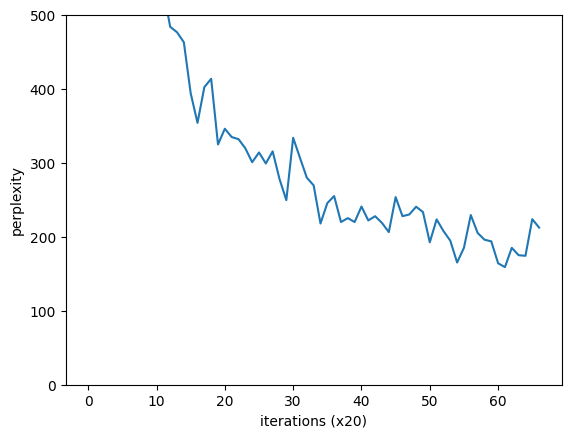

evaluating perplexity ...
234 / 235
test perplexity:  216.77492


In [ ]:
#GRUの学習
import numpy
import sys
import time

# ハイパーパラメータの設定
batch_size = 20        # 1ミニバッチのサンプル数（Truncated BPTTでまとめて処理）
wordvec_size = 100     # 埋め込み（単語ベクトル）の次元数
hidden_size = 100      # GRUの隠れ状態ベクトルの次元数
time_size = 35         # 1回のBPTTで展開する時間長（35トークンぶんを一度に学習）
lr = 20.0              # 学習率（SGD）。RNN系の古典実装では比較的大きめ＋勾配クリップで安定化が定番
max_epoch = 1          # 学習エポック数
max_grad = 0.25        # 勾配クリッピングの上限ノルム（爆発的勾配の抑制）

# 学習データの読み込み
corpus, word_to_id, id_to_word = load_data('train')    # 学習用コーパスと語彙辞書を取得
corpus_test, _, _ = load_data('test')                  # 評価用（テスト）コーパス
vocab_size = len(word_to_id)                           # 語彙数
xs = corpus[:-1]                                       # 入力系列（先頭〜最後-1）
ts = corpus[1:]                                        # 教師系列（入力を1語分だけシフト）

# モデルの生成
model = GRUlm(vocab_size, wordvec_size, hidden_size)   # GRUベースの言語モデル
optimizer = SGD(lr)                                    # 単純SGDを使用
trainer = GRUlmTrainer(model, optimizer)               # 学習ループを司るトレーナ

# ① 勾配クリッピングを適用して学習
trainer.fit(xs, ts,                                  # コーパス（入力と教師）
            max_epoch,                               # エポック数
            batch_size,                              # バッチサイズ
            time_size,                               # Truncated BPTT長
            max_grad,                                # 勾配クリッピング閾値
            eval_interval=20)                        # 進捗表示の間隔
trainer.plot(ylim=(0, 500))                          # 学習曲線をプロット

# ② テストデータで評価
model.reset_state()                                   # 連結シーケンスの影響を消すため評価前に状態をリセット
ppl_test = eval_perplexity(model, corpus_test)        # テストコーパス全体のパープレキシティを算出
print('test perplexity: ', ppl_test)                  # 評価指標を表示

# ③ パラメータの保存
model.save_params()                                   # BaseModel.save_params() により学習済み重みを保存